# Multimodal RAG over *Attention Is All You Need*

**ITI Level 2 AI — Graduation Project · Extended Track**

This notebook builds and evaluates a Retrieval-Augmented Generation pipeline over a single,
deliberately chosen document: the original Transformer paper (Vaswani et al., 2017).

The paper was picked because it densely mixes **every content type a multimodal RAG system
has to handle**: prose, inline equations, 4 data tables, 2 architecture diagrams, and 3
attention-visualisation figures.

### Deviation from the brief (deliberate, documented)

The Extended Track suggests a YOLO/object-detection component. **This project does not use
YOLO.** There is nothing in this document YOLO is suited to detect — there are no discrete
objects in photographs; the images are schematic diagrams and data visualisations. The
multimodal requirement is instead satisfied by a **vision-language model (`gemma3:4b`)**
that reads and grounds the diagrams and figures. This is a substitution of technique, not a
reduction in scope.

### Everything runs locally

| Role | Model | Runs via |
|---|---|---|
| Text embedding | `nomic-embed-text` (768-dim) | Ollama |
| Vision-language | `gemma3:4b` | Ollama |
| Answer generation | `llama3.2:1b` | Ollama |

No cloud API is called at any point.

> **Reproducibility:** this notebook is written to survive *Kernel → Restart & Run All*.
> Every cell depends only on cells above it. Expect roughly 3–5 minutes end to end, dominated
> by the vision-model and evaluation cells.

## 0 · Environment & paths

The first cell locates the project root by walking up from the working directory until it
finds the source PDF, then `chdir`s there. This is what makes the notebook runnable from
either `notebooks/` or the repository root without editing any paths.

In [1]:
import json
import os
import re
import time
from pathlib import Path

import numpy as np


def find_project_root(marker="Attention_is_all_you_need_paper.pdf"):
    """Walk upward from the CWD until the marker file is found."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate {marker!r} in {here} or any parent directory."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

PDF = "Attention_is_all_you_need_paper.pdf"
PROCESSED = Path("data/processed")
IMAGES_DIR = PROCESSED / "images"
VECTOR_STORE = Path("data/vector_store")
PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("project root :", PROJECT_ROOT)
print("source PDF   :", Path(PDF).exists())

project root : C:\Users\Ali Ahmed\OneDrive - Alexandria National University\Desktop\ITI_level_2_AI\Final_project
source PDF   : True


In [2]:
import chromadb
import fitz  # PyMuPDF
import ollama
from rank_bm25 import BM25Okapi

EMBED_MODEL = "nomic-embed-text"
VLM_MODEL = "gemma3:4b"
LLM_MODEL = "llama3.2:1b"

available = {m.model for m in ollama.list().models}
for name in (EMBED_MODEL, VLM_MODEL, LLM_MODEL):
    tag = name if ":" in name else f"{name}:latest"
    status = "found" if tag in available or name in available else "MISSING - run: ollama pull " + name
    print(f"{name:20} {status}")

nomic-embed-text     found
gemma3:4b            found
llama3.2:1b          found


## 2.1 · Load & Inspect

Before deciding how to chunk anything, we inspect what the document actually contains.

In [3]:
doc = fitz.open(PDF)

total_chars = 0
print(f"{'page':>5}  {'chars':>6}  {'images':>6}  {'vectors':>7}  note")
for pno in range(doc.page_count):
    page = doc[pno]
    text = page.get_text()
    total_chars += len(text)
    n_images = len(page.get_images(full=True))
    n_draw = len(page.get_drawings())
    note = ""
    if n_images:
        note = "raster figure"
    elif n_draw > 100:
        note = "vector figure (attention viz)"
    print(f"{pno + 1:>5}  {len(text):>6}  {n_images:>6}  {n_draw:>7}  {note}")

print(f"\ntotal pages: {doc.page_count}   total extracted characters: {total_chars:,}")

 page   chars  images  vectors  note
    1    2858       0        3  
    2    4256       0        0  
    3    1827       1        0  raster figure
    4    2508       2        8  raster figure
    5    3193       0        1  
    6    3473       0        3  
    7    3321       0        0  
    8    3194       0        8  
    9    2973       0       53  
   10    3112       0       33  
   11    3216       0        0  
   12    3214       0        0  


   13     794       0      624  vector figure (attention viz)


   14     778       0     1030  vector figure (attention viz)


   15     781       0      947  vector figure (attention viz)

total pages: 15   total extracted characters: 39,498


### What the inspection tells us

| Question | Answer |
|---|---|
| How many documents / pages? | **1 document, 15 pages** |
| What format? | A single born-digital PDF (LaTeX/NeurIPS style) |
| Did anything fail to parse? | **No.** Every page yields extractable text |
| Does anything need OCR? | **No.** The text layer is intact — this is not a scan |

Two structural facts drive the entire chunking design:

1. **Pages 3–4 contain raster images** (`get_images()` returns objects) — these are Figure 1
   and Figure 2, the architecture diagrams.
2. **Pages 13–15 contain 600–1000 vector drawing operations each but no raster images.** These
   are Figures 3–5, the attention visualisations. They are *drawn*, not embedded, so
   `get_images()` finds nothing and they must be rendered from the page instead.

Missing that second point is the kind of thing that silently produces a figure-less pipeline.

**Pages 11–12 (References) are excluded from the index entirely** — a bibliography retrieves
poorly and answers no meaningful question about the paper's content.

## 2.2 · Chunking Strategy

### Why not fixed-size chunks with overlap

The conventional default — ~500 tokens with ~50 token overlap — is a *concession to not
knowing where the semantic boundaries are*. In this document we do know, so a
**structure-aware, modality-specific** strategy strictly dominates it:

| Strategy | Problem on this document |
|---|---|
| Fixed-size + overlap | Splits Table 2 mid-row; half a table retrieves as noise. Cuts §3.2.1 in two, so "why divide by √d_k" loses its own explanation |
| **Section-based (chosen)** | Each chunk is a complete, self-contained unit of meaning with a natural citation label |

**Chunk size is therefore an output, not a parameter.** Sections run 9–490 words (mean ~176),
comfortably inside `nomic-embed-text`'s 2048-token window.

**Overlap is zero, by design.** Overlap exists to stop a fixed-size window severing an idea.
With section boundaries nothing is severed, so overlap would only duplicate text, inflate the
index, and let one section's content be cited under a neighbour's ID.

### The four content types

| Modality | Unit | Retrievable text |
|---|---|---|
| `text` | one subsection | section heading + body prose |
| `table` | one table | caption + lead-in sentence + markdown table |
| `figure_diagram` | Figure 1–2 | caption + **VLM-generated structural description** |
| `figure_attnviz` | Figure 3–5 | the paper's own caption (authoritative) |

### 2.2a · Prose — font-based section detection

This paper's LaTeX style renders section headers in a distinct medium-weight font
(`NimbusRomNo9L-Medi`) that body text never uses. A standalone medium-weight line matching
`^[1-9](\.[1-9]){0,2}$` is a section *number*; the next standalone medium-weight line is its
*title*.

Two real bugs were found and fixed here — both are preserved in the code below because they
generalise to any LaTeX paper:

1. **Bold numbers inside tables masqueraded as section headers.** The bold BLEU/PPL values in
   Tables 2–3 (`41.29`, `4.33`) use the same medium-weight font as real headings and matched a
   looser number regex, opening bogus sections. Fixed by requiring every dot-separated
   component to be a *single digit* — real headings here never exceed `6.3`.
2. **Table regions swallowed the discussion paragraphs that follow them.** A caption-based
   "skip until the next header" rule over-skipped, because Tables 3 and 4 are each followed by
   discussion prose with no header in between. Fixed with hand-verified y-coordinate bounding
   boxes per table, cross-checked against `page.find_tables()` where it agreed.

In [4]:
TOP_NAMES = {"Abstract", "Conclusion", "Acknowledgements"}
STOP_AT = {"References"}
RUN_IN_LABELS = {"Encoder:", "Decoder:", "Residual Dropout", "Label Smoothing"}

# Bug fix 1: every dot-separated component must be a SINGLE digit, so bold table
# values like "41.29" can never be mistaken for a section number.
NUM_RE = re.compile(r"^[1-9](\.[1-9]){0,2}$")

# Bug fix 2: hand-verified table extents (0-indexed page -> excluded y-range).
TABLE_REGIONS = {
    5: (65, 190),   # Table 1
    7: (65, 246),   # Table 2
    8: (65, 390),   # Table 3
    9: (65, 241),   # Table 4
}

sections, current, pending_number = [], None, None


def open_section(sec_id, title, page):
    global current
    current = {"id": sec_id, "title": title, "page_start": page + 1, "body": []}
    sections.append(current)


stop_walk = False
for pno in range(0, 10):  # pages 11+ are References onward -> excluded
    if stop_walk:
        break
    page = doc[pno]
    excl = TABLE_REGIONS.get(pno)
    for block in sorted(page.get_text("dict")["blocks"], key=lambda b: b["bbox"][1]):
        if stop_walk or "lines" not in block:
            continue
        for line in block["lines"]:
            spans = line["spans"]
            if not spans:
                continue
            text = "".join(s["text"] for s in spans).strip()
            if not text:
                continue

            y0 = line["bbox"][1]
            if y0 > 735:
                continue                      # page-footer zone
            if excl and excl[0] <= y0 <= excl[1]:
                continue                      # inside a known table region

            if all("Medi" in s["font"] for s in spans):
                if text in STOP_AT:
                    stop_walk = True
                    break
                if pending_number:
                    open_section(pending_number, text, pno)
                    pending_number = None
                    continue
                if NUM_RE.match(text):
                    pending_number = text
                    continue
                if text in TOP_NAMES:
                    open_section(text, text, pno)
                    continue
                if text in RUN_IN_LABELS and current is not None:
                    current["body"].append(text)
                    continue
            if current is not None:
                current["body"].append(text)

prose_chunks = []
for s in sections:
    body = re.sub(r"\s+", " ", " ".join(s["body"])).strip()
    label = f"{s['id']} {s['title']}" if not s["id"][0].isalpha() else s["title"]
    prose_chunks.append({
        "id": s["id"], "title": s["title"], "page_start": s["page_start"],
        "word_count": len(body.split()), "text": f"{label}. {body}",
    })

# Drop header-only chunks (e.g. "6 Results" immediately followed by "6.1").
dropped = [c["id"] for c in prose_chunks if c["word_count"] == 0]
prose_chunks = [c for c in prose_chunks if c["word_count"] > 0]

(PROCESSED / "prose_chunks.json").write_text(json.dumps(prose_chunks, indent=2), encoding="utf-8")

counts = [c["word_count"] for c in prose_chunks]
print(f"prose chunks: {len(prose_chunks)}   dropped empty headers: {dropped}")
print(f"words per chunk: min={min(counts)} max={max(counts)} mean={sum(counts)//len(counts)}")
for c in prose_chunks[:6]:
    print(f"  [{c['id']:>14}] p{c['page_start']:>2} {c['word_count']:>4}w  {c['title']}")
print("  ...")

prose chunks: 23   dropped empty headers: ['6']
words per chunk: min=9 max=490 mean=176
  [      Abstract] p 1  317w  Abstract
  [             1] p 2  278w  Introduction
  [             2] p 2  260w  Background
  [             3] p 2  114w  Model Architecture
  [           3.1] p 3  209w  Encoder and Decoder Stacks
  [           3.2] p 3   82w  Attention
  ...


### 2.2b · Tables — markdown, with context

Each table becomes **one chunk**, because a table is a single argument: splitting it destroys
the comparison it exists to make.

Each chunk carries three things:
1. the **caption** (what the table is),
2. a **lead-in sentence** pulled from the prose that first discusses it (why it matters), and
3. the table itself rendered as **markdown** (an LLM-legible grid).

`page.find_tables()` only auto-detected Tables 3 and 4, and mangled Table 3's merged
`(A)`–`(E)` row-groups. Tables 1 and 2 it missed entirely. The cells below were therefore
transcribed once from the raw `(x, y, text)` span dump and hard-coded — consistent with this
being a **bespoke single-document pipeline**, not a general-purpose table parser.

In [5]:
CAPTIONS = {}
for pno, (y0, y1) in TABLE_REGIONS.items():
    lines = []
    for block in sorted(doc[pno].get_text("dict")["blocks"], key=lambda b: b["bbox"][1]):
        if "lines" not in block:
            continue
        for line in block["lines"]:
            if y0 <= line["bbox"][1] <= y1:
                t = "".join(s["text"] for s in line["spans"]).strip()
                if t:
                    lines.append(t)
    caption = " ".join(lines)
    CAPTIONS[pno] = caption[: caption.find("  ")] if "  " in caption else caption

# Lead-in sentences, located by regexing the prose chunks for "Table N" mentions.
CONTEXT = {}
for pno, num in {5: "1", 7: "2", 8: "3", 9: "4"}.items():
    hits = []
    for c in prose_chunks:
        hits += [m.group().strip() for m in re.finditer(rf"[^.]*Table {num}[^.]*\.", c["text"])]
    CONTEXT[pno] = hits[0] if hits else ""
    print(f"Table {num} lead-in: {CONTEXT[pno][:95]}")

Table 1 lead-in: As noted in Table 1, a self-attention layer connects all positions with a constant number of se
Table 2 lead-in: On the WMT 2014 English-to-German translation task, the big transformer model (Transformer (big
Table 3 lead-in: We also experimented with using learned positional embeddings [9] instead, and found that the t
Table 4 lead-in: Our results in Table 4 show that despite the lack of task-specific tuning our model performs su


In [6]:
TABLE_1_MD = """| Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length |
|---|---|---|---|
| Self-Attention | O(n^2 * d) | O(1) | O(1) |
| Recurrent | O(n * d^2) | O(n) | O(n) |
| Convolutional | O(k * n * d^2) | O(1) | O(log_k(n)) |
| Self-Attention (restricted) | O(r * n * d) | O(1) | O(n/r) |"""

TABLE_2_MD = """| Model | BLEU EN-DE | BLEU EN-FR | Training Cost (FLOPs) EN-DE | Training Cost (FLOPs) EN-FR |
|---|---|---|---|---|
| ByteNet | 23.75 | - | - | - |
| Deep-Att + PosUnk | - | 39.2 | - | 1.0e20 |
| GNMT + RL | 24.6 | 39.92 | 2.3e19 | 1.4e20 |
| ConvS2S | 25.16 | 40.46 | 9.6e18 | 1.5e20 |
| MoE | 26.03 | 40.56 | 2.0e19 | 1.2e20 |
| Deep-Att + PosUnk Ensemble | - | 40.4 | - | 8.0e20 |
| GNMT + RL Ensemble | 26.30 | 41.16 | 1.8e20 | 1.1e21 |
| ConvS2S Ensemble | 26.36 | 41.29 | 7.7e19 | 1.2e21 |
| Transformer (base model) | 27.3 | 38.1 | 3.3e18 (combined) | 3.3e18 (combined) |
| Transformer (big) | 28.4 | 41.8 | 2.3e19 (combined) | 2.3e19 (combined) |"""

TABLE_3_MD = """| Row | N | d_model | d_ff | h | d_k | d_v | P_drop | eps_ls | train steps | PPL (dev) | BLEU (dev) | params (x10^6) |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| base | 6 | 512 | 2048 | 8 | 64 | 64 | 0.1 | 0.1 | 100K | 4.92 | 25.8 | 65 |
| (A) | - | - | - | 1 | 512 | 512 | - | - | - | 5.29 | 24.9 | - |
| (A) | - | - | - | 4 | 128 | 128 | - | - | - | 5.00 | 25.5 | - |
| (A) | - | - | - | 16 | 32 | 32 | - | - | - | 4.91 | 25.8 | - |
| (A) | - | - | - | 32 | 16 | 16 | - | - | - | 5.01 | 25.4 | - |
| (B) | - | - | - | - | 16 | - | - | - | - | 5.16 | 25.1 | 58 |
| (B) | - | - | - | - | 32 | - | - | - | - | 5.01 | 25.4 | 60 |
| (C) | 2 | - | - | - | - | - | - | - | - | 6.11 | 23.7 | 36 |
| (C) | 4 | - | - | - | - | - | - | - | - | 5.19 | 25.3 | 50 |
| (C) | 8 | - | - | - | - | - | - | - | - | 4.88 | 25.5 | 80 |
| (C) | - | 256 | - | - | 32 | 32 | - | - | - | 5.75 | 24.5 | 28 |
| (C) | - | 1024 | - | - | 128 | 128 | - | - | - | 4.66 | 26.0 | 168 |
| (C) | - | - | 1024 | - | - | - | - | - | - | 5.12 | 25.4 | 53 |
| (C) | - | - | 4096 | - | - | - | - | - | - | 4.75 | 26.2 | 90 |
| (D) | - | - | - | - | - | - | 0.0 | - | - | 5.77 | 24.6 | - |
| (D) | - | - | - | - | - | - | 0.2 | - | - | 4.95 | 25.5 | - |
| (D) | - | - | - | - | - | - | - | 0.0 | - | 4.67 | 25.3 | - |
| (D) | - | - | - | - | - | - | - | 0.2 | - | 5.47 | 25.7 | - |
| (E) | - | - | - | - | - | - | - | - | - | 4.92 | 25.7 | - |
| big | 6 | 1024 | 4096 | 16 | - | - | 0.3 | - | 300K | 4.33 | 26.4 | 213 |

Row-group notes: (A) varies the number of attention heads h and the key/value dimensions
d_k, d_v at constant computation. (B) varies only d_k. (C) varies model size (N, then
d_model/d_ff). (D) varies regularisation (dropout P_drop, then label smoothing eps_ls).
(E) replaces sinusoidal positional encoding with a learned positional embedding.
Unlisted cells in a row are identical to the base model, per the paper's own caption."""

TABLE_4_MD = """| Parser | Training | WSJ 23 F1 |
|---|---|---|
| Vinyals & Kaiser et al. (2014) | WSJ only, discriminative | 88.3 |
| Petrov et al. (2006) | WSJ only, discriminative | 90.4 |
| Zhu et al. (2013) | WSJ only, discriminative | 90.4 |
| Dyer et al. (2016) | WSJ only, discriminative | 91.7 |
| Transformer (4 layers) | WSJ only, discriminative | 91.3 |
| Zhu et al. (2013) | semi-supervised | 91.3 |
| Huang & Harper (2009) | semi-supervised | 91.3 |
| McClosky et al. (2006) | semi-supervised | 92.1 |
| Vinyals & Kaiser et al. (2014) | semi-supervised | 92.1 |
| Transformer (4 layers) | semi-supervised | 92.7 |
| Luong et al. (2015) | multi-task | 93.0 |
| Dyer et al. (2016) | generative | 93.3 |"""

TABLES_MD = {5: TABLE_1_MD, 7: TABLE_2_MD, 8: TABLE_3_MD, 9: TABLE_4_MD}
TABLE_IDS = {5: "Table 1", 7: "Table 2", 8: "Table 3", 9: "Table 4"}

table_chunks = []
for pno in sorted(TABLE_REGIONS):
    text = f"{CAPTIONS[pno]}\n\nContext: {CONTEXT[pno]}\n\n{TABLES_MD[pno]}"
    table_chunks.append({
        "id": TABLE_IDS[pno], "title": CAPTIONS[pno][:90], "page_start": pno + 1,
        "modality": "table", "word_count": len(text.split()), "text": text,
        "image_path": None,
    })

(PROCESSED / "table_chunks.json").write_text(json.dumps(table_chunks, indent=2), encoding="utf-8")
for c in table_chunks:
    print(f"[{c['id']}] p{c['page_start']:>2} {c['word_count']:>4}w")

[Table 1] p 6  176w
[Table 2] p 8  303w
[Table 3] p 9  830w
[Table 4] p10  296w


### 2.2c · Figures — extraction

Figure 1 and Figure 2 are raster images; Figures 3–5 are **vector drawings**. Rather than
branching on that difference, every figure is rendered from its page region with
`get_pixmap(clip=..., matrix=Matrix(3, 3))` (~216 dpi), which captures raster content, vector
content, and any text labels overlaid on top — uniformly.

The crop boxes below were derived from image bounding boxes (Figures 1–2) and from the union
of vector drawing extents (Figures 3–5), then each output was inspected by eye. Figure 2's box
was widened after the first attempt clipped the "Scaled Dot-Product Attention" label.

In [7]:
ZOOM = 3  # ~216 dpi


def render_figure(page_idx, rect, out_name):
    pix = doc[page_idx].get_pixmap(clip=fitz.Rect(*rect), matrix=fitz.Matrix(ZOOM, ZOOM))
    path = IMAGES_DIR / out_name
    pix.save(str(path))
    return str(path).replace("\\", "/")


def caption_block(page_idx, label):
    """Return the full multi-line caption block beginning with e.g. 'Figure 3'."""
    for block in doc[page_idx].get_text("dict")["blocks"]:
        if "lines" not in block:
            continue
        text = " ".join(
            "".join(s["text"] for s in line["spans"]) for line in block["lines"]
        ).strip()
        if text.startswith(label):
            return " ".join(text.split())
    raise ValueError(f"caption {label!r} not found on page {page_idx + 1}")


DIAGRAMS = [
    {"id": "Figure 1", "page_idx": 2, "rect": (190, 68, 422, 400), "image": "figure1.png"},
    {"id": "Figure 2", "page_idx": 3, "rect": (140, 65, 474, 271), "image": "figure2.png"},
]
ATTNVIZ = [
    {"id": "Figure 3", "page_idx": 12, "rect": (110, 82, 508, 305), "image": "figure3.png"},
    {"id": "Figure 4", "page_idx": 13, "rect": (115, 118, 508, 610), "image": "figure4.png"},
    {"id": "Figure 5", "page_idx": 14, "rect": (115, 133, 504, 599), "image": "figure5.png"},
]

figure_records = []
for fig in DIAGRAMS + ATTNVIZ:
    path = render_figure(fig["page_idx"], fig["rect"], fig["image"])
    caption = caption_block(fig["page_idx"], fig["id"])
    figure_records.append({
        "id": fig["id"], "page_start": fig["page_idx"] + 1,
        "modality": "figure_diagram" if fig in DIAGRAMS else "figure_attnviz",
        "caption": caption, "image_path": path,
    })
    print(f"{fig['id']:>9}  {path}")

 Figure 1  data/processed/images/figure1.png
 Figure 2  data/processed/images/figure2.png


 Figure 3  data/processed/images/figure3.png


 Figure 4  data/processed/images/figure4.png


 Figure 5  data/processed/images/figure5.png


Figure 1 - the architecture diagram the VLM will describe:


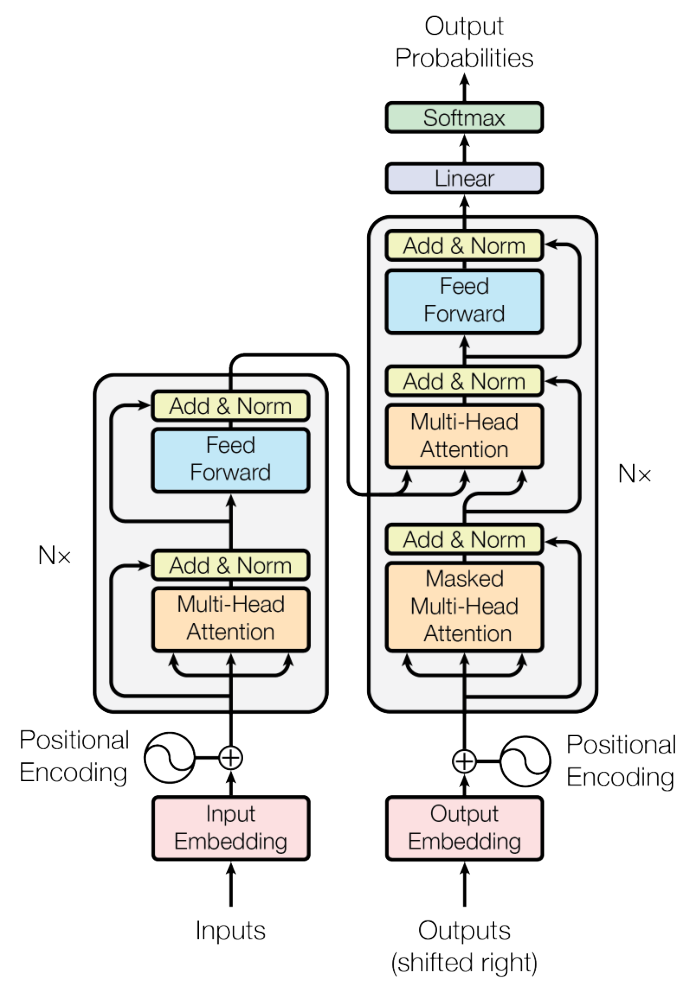

In [8]:
from IPython.display import Image, display

print("Figure 1 - the architecture diagram the VLM will describe:")
display(Image(filename=str(IMAGES_DIR / "figure1.png"), width=330))

## 2.5 · Vision Component — the VLM, used twice and differently

This is the project's answer to the Extended Track requirement, in place of YOLO.

`gemma3:4b` is applied in **two distinct roles**, and the distinction is the interesting part:

| | Figures 1–2 (diagrams) | Figures 3–5 (attention viz) |
|---|---|---|
| **At ingestion** | VLM writes a structural description → indexed | Paper's own caption is indexed; **VLM not used** |
| **At query time** | VLM re-reads the image, question-aware | VLM re-reads it, **anchored to the caption** |

### Why the asymmetry — an empirical finding, not a preference

The attention-visualisation figures were tested directly, and the results decided the design:

- **Reading rotated text: excellent.** Those figures render their token labels rotated 90°.
  `gemma3:4b` transcribed them essentially perfectly in *both* the original orientation and a
  manually un-rotated copy, so no pre-rotation step is needed.
- **Reasoning about attention strength: unreliable.** Asked which word Figure 3 highlights, it
  confidently answered **"difficult"**. The correct answer is **"making"**.

So for these three figures the paper's own caption — written by the authors, verified accurate —
is the better retrievable text, and the VLM's job at query time is narrowed to *describing what
is visible, anchored to that caption*, rather than *inferring* attention weights from pixels.

The stored diagram descriptions come with a caveat that is honest to state: **they are noisy and
non-deterministic.** Two runs over Figure 1 produced different, each partially-wrong descriptions
(one merged the encoder and decoder stacks; the other dropped the decoder entirely). They are
therefore treated as a **retrieval aid** — text that helps the right figure surface for a query —
and never as ground truth. The image itself remains the source of truth, which is exactly why
`image_path` is carried through to the answer.

In [9]:
DIAGRAM_PROMPT = """This image is an architecture diagram from the paper "Attention Is All You Need".
Describe it structurally for someone who cannot see the image, so the description can be
used to answer questions about the architecture. Cover:
1. What are the distinct components/blocks (name them).
2. How are they connected -- what feeds into what, in what order.
3. Any repeated/stacked structures (e.g. "Nx" meaning the block repeats N times).
4. Any labeled inputs/outputs.
Be precise about connections (arrows), not just a list of boxes. Do not offer further help
or ask a follow-up question at the end -- end after the description itself."""

figure_chunks = []
for rec in figure_records:
    text = rec["caption"]
    if rec["modality"] == "figure_diagram":
        t0 = time.time()
        resp = ollama.chat(
            model=VLM_MODEL,
            messages=[{"role": "user", "content": DIAGRAM_PROMPT, "images": [rec["image_path"]]}],
        )
        description = re.sub(r"\n+---\n+Would you like.*$", "", resp.message.content.strip(), flags=re.DOTALL)
        text = f"{rec['caption']}\n\nStructural description (gemma3:4b): {description.strip()}"
        print(f"{rec['id']}: VLM described in {time.time() - t0:.1f}s ({resp.eval_count} tokens)")

    figure_chunks.append({
        "id": rec["id"], "title": rec["id"], "page_start": rec["page_start"],
        "modality": rec["modality"], "word_count": len(text.split()),
        "text": text, "image_path": rec["image_path"],
    })

(PROCESSED / "figure_chunks.json").write_text(json.dumps(figure_chunks, indent=2), encoding="utf-8")
for c in figure_chunks:
    print(f"[{c['id']}] {c['modality']:<15} {c['word_count']:>4}w  {c['image_path']}")

Figure 1: VLM described in 21.1s (553 tokens)


Figure 2: VLM described in 11.7s (743 tokens)
[Figure 1] figure_diagram   425w  data/processed/images/figure1.png
[Figure 2] figure_diagram   488w  data/processed/images/figure2.png
[Figure 3] figure_attnviz    56w  data/processed/images/figure3.png
[Figure 4] figure_attnviz    46w  data/processed/images/figure4.png
[Figure 5] figure_attnviz    45w  data/processed/images/figure5.png


In [10]:
# The VLM's structural read of Figure 1, as indexed:
print(figure_chunks[0]["text"][:1100])

Figure 1: The Transformer - model architecture.

Structural description (gemma3:4b): The diagram illustrates the architecture of a Transformer model, as described in the paper "Attention Is All You Need". The core structure consists of multiple identical blocks stacked sequentially.

Here’s a breakdown of the components and connections:

**1. Input Processing:**

*   **Input Embedding:** The input consists of ‘N’ elements, and each element is first transformed into an embedding vector.
*   **Positional Encoding:**  A positional encoding vector is added to each input embedding. This encoding provides information about the position of each element in the sequence.
*   **Output Embedding:** The output of the positional encoding stage (the N embedded vectors with positional information) is then transformed into an output embedding vector.

**2. Block Structure (Repeated Nx Times):**

Each of the ‘N’ elements has its own processing path through a repeated block. Within each block, there are

## 2.3 · Unified schema, embeddings & vector store

### One index, not four

A tempting design is one store per modality with a router in front. This pipeline deliberately
uses **a single unified index**, because the router would have to guess the answer's modality
*before* retrieving — and users don't phrase questions that way. "How much does a single
attention head cost in BLEU?" is answered by a *table*, but nothing in the wording says so.

The key insight that makes one index work:

> **The embedding model is modality-blind — it only ever sees strings.**

A table is embedded as its markdown, a figure as its caption plus description. `modality` and
`image_path` are carried as **metadata for downstream routing** (when to call the VLM, what to
render, how to cite), never as inputs to the embedding step.

In [11]:
unified = []
for c in prose_chunks:
    unified.append({"id": c["id"], "text": c["text"], "metadata": {
        "modality": "text", "section": c["title"], "page": c["page_start"], "image_path": None}})
for c in table_chunks:
    unified.append({"id": c["id"], "text": c["text"], "metadata": {
        "modality": "table", "section": c["id"], "page": c["page_start"], "image_path": None}})
for c in figure_chunks:
    unified.append({"id": c["id"], "text": c["text"], "metadata": {
        "modality": c["modality"], "section": c["id"], "page": c["page_start"],
        "image_path": c["image_path"]}})

ids = [c["id"] for c in unified]
assert len(ids) == len(set(ids)), "duplicate chunk ids"
(PROCESSED / "all_chunks.json").write_text(json.dumps(unified, indent=2), encoding="utf-8")

from collections import Counter
print(f"{len(unified)} unified chunks")
for modality, n in sorted(Counter(c["metadata"]["modality"] for c in unified).items()):
    print(f"  {modality:<16} {n}")

32 unified chunks
  figure_attnviz   3
  figure_diagram   2
  table            4
  text             23


### The asymmetric-prefix detail that silently degrades retrieval if missed

`nomic-embed-text` was trained with **task prefixes**: corpus text must be embedded as
`search_document: ...` and queries as `search_query: ...`. Omitting them, or — worse — using
the same prefix on both sides, measurably degrades retrieval while *appearing* to work fine.

Both sides are defined here, together, so they cannot drift apart.

In [12]:
DOCUMENT_PREFIX = "search_document: "
QUERY_PREFIX = "search_query: "

t0 = time.time()
resp = ollama.embed(model=EMBED_MODEL, input=[DOCUMENT_PREFIX + c["text"] for c in unified])
embeddings = resp.embeddings
for chunk, vec in zip(unified, embeddings):
    chunk["embedding"] = list(vec)

(PROCESSED / "all_chunks_embedded.json").write_text(json.dumps(unified), encoding="utf-8")
print(f"embedded {len(embeddings)} chunks in {time.time() - t0:.1f}s")
print(f"dimensionality: {sorted({len(v) for v in embeddings})}")

embedded 32 chunks in 2.0s
dimensionality: [768]


In [13]:
client = chromadb.PersistentClient(path=str(VECTOR_STORE))
try:
    client.delete_collection("attention_paper")   # idempotent: safe to re-run
except Exception:
    pass

collection = client.create_collection(name="attention_paper", metadata={"hnsw:space": "cosine"})
collection.add(
    ids=[c["id"] for c in unified],
    embeddings=[c["embedding"] for c in unified],
    documents=[c["text"] for c in unified],
    # Chroma rejects None metadata values, so drop empty keys rather than store null
    metadatas=[{k: v for k, v in c["metadata"].items() if v is not None} for c in unified],
)
print(f"persisted {collection.count()} chunks to {VECTOR_STORE}/ (cosine space)")

persisted 32 chunks to data\vector_store/ (cosine space)


## 2.4 · Retrieval & Prompting

### Hybrid retrieval: dense + BM25, fused with RRF

Dense retrieval alone is the obvious choice and it mostly works. It has one weakness that
matters acutely here: **embeddings encode topic, not digits.** A query naming a specific BLEU
or parameter value embeds almost identically to one naming a different value, and this paper
contains several structurally similar numeric tables.

BM25 is the exact complement — it matches literal tokens and ignores semantics. Over a
32-chunk corpus it costs nothing to compute.

The two are combined with **Reciprocal Rank Fusion**:

$$\text{score}(d) = \frac{1}{k + \text{rank}_{\text{dense}}(d)} + \frac{1}{k + \text{rank}_{\text{bm25}}(d)}, \quad k = 60$$

RRF uses only **ranks**, never raw scores — which matters because a cosine *distance* (lower is
better, ~0–2) and a BM25 *score* (higher is better, unbounded) are not comparable quantities and
any attempt to normalise them into one number invents a scale that doesn't exist.

In [14]:
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())


bm25_ids = [c["id"] for c in unified]
bm25 = BM25Okapi([tokenize(c["text"]) for c in unified])
chunk_by_id = {c["id"]: c for c in unified}

TOP_K = 4
RRF_K = 60


def embed_query(question):
    return ollama.embed(model=EMBED_MODEL, input=QUERY_PREFIX + question).embeddings[0]


def hybrid_retrieve(question, k=TOP_K, explain=False):
    """Dense (Chroma/cosine) + BM25, fused by Reciprocal Rank Fusion.

    Returns (top-k chunks, best dense distance). The distance doubles as the
    'is this question even about the paper?' signal used in section 2.4b.
    """
    dense_res = collection.query(query_embeddings=[embed_query(question)], n_results=len(unified))
    dense = list(zip(dense_res["ids"][0], dense_res["distances"][0]))
    bm25_scores = sorted(zip(bm25_ids, bm25.get_scores(tokenize(question))), key=lambda x: -x[1])

    dense_rank = {cid: i + 1 for i, (cid, _) in enumerate(dense)}
    bm25_rank = {cid: i + 1 for i, (cid, _) in enumerate(bm25_scores)}

    fused = sorted(
        ({"id": cid,
          "dense_rank": dense_rank[cid],
          "bm25_rank": bm25_rank[cid],
          "score": 1 / (RRF_K + dense_rank[cid]) + 1 / (RRF_K + bm25_rank[cid])}
         for cid in dense_rank),
        key=lambda x: -x["score"],
    )[:k]

    if explain:
        print(f"Q: {question}\n")
        print(f"  {'dense (cosine)':<34}{'bm25 (lexical)':<30}")
        for i in range(5):
            d_id, d_dist = dense[i]
            b_id, b_score = bm25_scores[i]
            print(f"  {i+1}. {d_id:<12} {d_dist:>6.3f}          {i+1}. {b_id:<12} {b_score:>7.2f}")
        print(f"\n  fused top-{k} (RRF):")
        for f in fused:
            meta = chunk_by_id[f["id"]]["metadata"]
            print(f"    {f['id']:<12} score={f['score']:.5f}  "
                  f"dense#{f['dense_rank']:<3} bm25#{f['bm25_rank']:<3} [{meta['modality']}]")

    return [chunk_by_id[f["id"]] for f in fused], dense[0][1]


_ = hybrid_retrieve("How much BLEU is lost with a single attention head?", explain=True)

Q: How much BLEU is lost with a single attention head?

  dense (cosine)                    bm25 (lexical)                
  1. 3.2.2         0.366          1. 3.2.1           7.99
  2. Figure 4      0.368          2. Abstract        7.20
  3. 3.2           0.386          3. Figure 2        7.19
  4. 3.2.3         0.387          4. 6.2             7.13
  5. Figure 5      0.390          5. 3.2.2           7.01

  fused top-4 (RRF):
    3.2.2        score=0.03178  dense#1   bm25#5   [text]
    3.2          score=0.03102  dense#3   bm25#6   [text]
    Figure 2     score=0.03102  dense#6   bm25#3   [figure_diagram]
    6.2          score=0.03055  dense#7   bm25#4   [text]


Notice what happened above: the dense ranking and the lexical ranking disagree, and fusion
takes the chunks that *both* signals like. That disagreement is precisely the value BM25 adds.

### 2.4b · Guard rails — not every input deserves a pipeline

An early version ran the full pipeline on *every* input. A bare **"who are you?"** retrieved two
figure chunks, invoked the vision model **twice**, and answered *"the model is a Transformer
model."* Slow, expensive, and wrong.

Three layers now sit in front, each doing the job it measurably does best:

| Layer | Mechanism | Cost | Catches |
|---|---|---|---|
| 1 | Exact rules | **~4 ms** | `hi`, `thanks`, `who are you?` |
| 2 | LLM classifier (constrained JSON) | **~100 ms** | `hiiii`, `wasssuppp`, `heyyy there` |
| 3 | Embedding distance threshold | **~120 ms** | `tell me a joke`, `capital of France` |

**Why the LLM gets only three labels.** A four-label version that *also* asked the model whether
a question was about the paper scored **48–58%**, and mislabelled **9 genuine paper questions as
off-topic** — it would have refused to answer real questions, the worst possible failure. Judging
topicality requires knowing the corpus, which a 1B model does not. Splitting the job —
**LLM for surface intent, embedding distance for topicality** — scored **89%**, with 12/12
greetings and 18/18 real questions correct.

A related trap: the first classifier prompt was full of Transformer vocabulary, which biased the
model into labelling *everything* a paper question. The prompt below is deliberately free of
topic keywords.

In [15]:
GREETINGS = {"hi", "hii", "hiya", "hello", "hey", "yo", "wassup", "sup", "good morning",
             "good afternoon", "good evening", "hi there", "hello there", "howdy"}
THANKS = {"thanks", "thank you", "thx", "ty", "appreciate it", "ok", "okay", "cool", "ok cool"}
FAREWELLS = {"bye", "goodbye", "see you", "see ya", "cya", "good night"}
IDENTITY_RE = re.compile(
    r"^(who|what)\s+(are|r)\s+(you|u)\b|^what\s+(can|do)\s+(you|u)\s+do\b"
    r"|^what\s+is\s+this\b|^how\s+do\s+(you|u)\s+work\b|^introduce\s+yourself\b|^help$")

SCOPE_BLURB = ('I answer questions about the paper "Attention Is All You Need" (Vaswani et al., '
               "2017) - the architecture, attention, positional encoding, training setup, "
               "results tables, and figures.")
GREETING_REPLY = f"Hello. {SCOPE_BLURB}"
IDENTITY_REPLY = f"I'm a retrieval-augmented assistant for a single document. {SCOPE_BLURB}"
OUT_OF_SCOPE_REPLY = ("That question doesn't appear to be about the paper, so I can't answer it "
                      f"from my sources. {SCOPE_BLURB}")

SCOPE_DISTANCE_THRESHOLD = 0.40

CLASSIFIER_SCHEMA = {"type": "object", "required": ["intent"], "properties": {
    "intent": {"type": "string", "enum": ["GREETING", "IDENTITY", "QUESTION"]}}}
CLASSIFIER_SYSTEM = """You label a single user message with one of three labels.

GREETING = a greeting, small talk, thanks, or goodbye. No real question is asked.
IDENTITY = the user asks what you are, who you are, or what you can do.
QUESTION = the user asks a real question about any subject.

Label only the message given. Do not answer it. Reply with JSON."""
CLASSIFIER_FEWSHOT = [("hello there", "GREETING"), ("thx man", "GREETING"), ("bye", "GREETING"),
                      ("yo!", "GREETING"), ("what can you do?", "IDENTITY"),
                      ("how do you work?", "IDENTITY"),
                      ("What is multi-head attention?", "QUESTION"),
                      ("what is the capital of France?", "QUESTION"),
                      ("how many encoder layers are there?", "QUESTION")]


def match_canned(question):
    """Layer 1: exact rules. Only fires on exact/short matches, so
    'hi, why do they scale by sqrt(d_k)?' still reaches retrieval."""
    norm = re.sub(r"[^a-z0-9\s]", "", question.lower()).strip()
    if not norm or norm in GREETINGS:
        return GREETING_REPLY
    if norm in THANKS:
        return "You're welcome. Ask me anything else about the paper."
    if norm in FAREWELLS:
        return "Goodbye."
    if len(norm.split()) <= 8 and IDENTITY_RE.search(norm):
        return IDENTITY_REPLY
    return None


def classify_intent(question):
    """Layer 2: LLM. Fails safe to QUESTION so an outage never blocks real questions."""
    messages = [{"role": "system", "content": CLASSIFIER_SYSTEM}]
    for text, label in CLASSIFIER_FEWSHOT:
        messages += [{"role": "user", "content": text},
                     {"role": "assistant", "content": json.dumps({"intent": label})}]
    messages.append({"role": "user", "content": question})
    try:
        resp = ollama.chat(model=LLM_MODEL, messages=messages,
                           format=CLASSIFIER_SCHEMA, options={"temperature": 0})
        return json.loads(resp.message.content)["intent"]
    except Exception:
        return "QUESTION"


for probe in ["hi", "wasssuppp", "who are you?", "What is multi-head attention?"]:
    canned = match_canned(probe)
    route = "rules" if canned else f"llm -> {classify_intent(probe)}"
    print(f"  {probe!r:34} {route}")

  'hi'                               rules


  'wasssuppp'                        llm -> GREETING
  'who are you?'                     rules
  'What is multi-head attention?'    llm -> QUESTION


### The prompt template

Three requirements shape it: answer **only** from context, **cite** the chunk IDs, and admit
when the context is insufficient. Chunk IDs double as human-readable citations — `[Table 2]`,
`[Figure 4]`, `[3.2.2]` — so no separate citation scheme is needed.

Two instructions were added in response to observed failures:
- *"never copy any sentence verbatim"* — `llama3.2:1b` was pasting whole VLM descriptions into
  its answers instead of synthesising.
- *"if the question is not about this paper, say so"* — last-resort defence behind the guard rails.

In [16]:
SYSTEM_INSTRUCTIONS = (
    'You are answering questions about the paper "Attention Is All You Need" using '
    "only the provided context. Cite which source(s) you used by their [id] (e.g. "
    '"[Table 2]", "[Figure 4]", "[3.2.2]"). If the context doesn\'t contain the '
    "answer, say so plainly instead of guessing. Answer entirely in your own words: "
    "summarize and synthesize, never copy or repeat any sentence from the context "
    "verbatim. Keep the answer focused and no longer than needed. "
    "If the question is not actually about this paper, do not try to answer it from "
    "the context anyway -- say that it is outside what you can answer from the paper."
)

ATTNVIZ_CAPTIONS = {
    "Figure 3": "An example of the attention mechanism following long-distance dependencies in "
                "the encoder self-attention in layer 5 of 6, for the word 'making' completing "
                "the phrase 'making...more difficult'.",
    "Figure 4": "Two attention heads, also in layer 5 of 6, apparently involved in anaphora "
                "resolution for the word 'its'.",
    "Figure 5": "Two attention heads exhibiting behaviour related to sentence structure, from "
                "the encoder self-attention at layer 5 of 6.",
}


def ground_figure_with_vlm(chunk, question):
    """Re-read the real pixels, question-aware. For attention-viz figures the paper's
    own caption is passed as an anchor, because the VLM was measured to mis-read
    attention strength when left to infer it unaided."""
    if chunk["metadata"]["modality"] == "figure_attnviz":
        prompt = (f"This image is from the paper 'Attention Is All You Need'. The paper's own "
                  f'caption says: "{ATTNVIZ_CAPTIONS.get(chunk["id"], "")}" A user asks: '
                  f'"{question}" Using the image AND the caption as your anchor (the caption is '
                  f"verified-accurate; don't contradict it), answer in 2-4 sentences. If the "
                  f"question asks which specific line is thickest, defer to the caption rather "
                  f"than guessing from pixels.")
    else:
        prompt = (f"This image is an architecture diagram from the paper 'Attention Is All You "
                  f'Need\'. A user asks: "{question}" Answer in 4-6 sentences using the diagram, '
                  f"describing only the relevant components and connections you can see.")

    resp = ollama.chat(model=VLM_MODEL, messages=[
        {"role": "user", "content": prompt, "images": [chunk["metadata"]["image_path"]]}])
    return resp.message.content.strip()


def build_prompt(chunks, question):
    blocks = []
    for chunk in chunks:
        text = chunk["text"]
        if chunk["metadata"]["modality"] in ("figure_diagram", "figure_attnviz"):
            text += " Additional detail grounded in the actual image: " + ground_figure_with_vlm(chunk, question)
        meta = chunk["metadata"]
        blocks.append(f"[{chunk['id']}] ({meta['modality']}, page {meta['page']})\n{text}")
    return f"{SYSTEM_INSTRUCTIONS}\n\nContext:\n" + "\n\n".join(blocks) + f"\n\nQuestion: {question}"


def answer(question, verbose=False):
    """Full pipeline: guard rails -> hybrid retrieval -> VLM grounding -> generation."""
    t0 = time.time()

    canned = match_canned(question)
    if canned:
        return {"answer": canned, "sources": [], "images": [], "route": "rules",
                "elapsed": time.time() - t0}

    intent = classify_intent(question)
    if intent in ("GREETING", "IDENTITY"):
        reply = GREETING_REPLY if intent == "GREETING" else IDENTITY_REPLY
        return {"answer": reply, "sources": [], "images": [], "route": f"llm:{intent}",
                "elapsed": time.time() - t0}

    chunks, best_distance = hybrid_retrieve(question)
    if best_distance > SCOPE_DISTANCE_THRESHOLD:
        return {"answer": OUT_OF_SCOPE_REPLY, "sources": [], "images": [],
                "route": f"out-of-scope(d={best_distance:.3f})", "elapsed": time.time() - t0}

    prompt = build_prompt(chunks, question)
    resp = ollama.chat(model=LLM_MODEL, messages=[{"role": "user", "content": prompt}])
    result = {
        "answer": resp.message.content.strip(),
        "sources": [c["id"] for c in chunks],
        "images": [c["metadata"]["image_path"] for c in chunks if c["metadata"].get("image_path")],
        "route": "rag", "elapsed": time.time() - t0,
        "prompt_tokens": resp.prompt_eval_count, "output_tokens": resp.eval_count,
    }
    if verbose:
        print(f"--- prompt sent to {LLM_MODEL} ({len(prompt)} chars) ---")
        print(prompt[:1500], "...\n")
    return result


demo = answer("Why do they divide the dot products by the square root of d_k?")
print(f"route={demo['route']}  {demo['elapsed']:.1f}s  sources={demo['sources']}")
print()
print(demo["answer"])

route=rag  5.0s  sources=['3.2.1', '3.2.2', 'Figure 2', 'Table 3']

The authors of the paper "Attention Is All You Need" divide the dot products of the query with the key by the square root of d_k in the Scaled Dot-Product Attention (SDPA) component. This is done to mitigate the issue of large gradients in the dot product calculations, which can occur when the dot products are highly magnified. By scaling the dot products, the authors aim to keep the gradients within a manageable range, allowing for stable training of the model.


### Guard rails in action

The same function, four very different inputs — note the cost of each route.

In [17]:
for probe in ["hi", "wasssuppp", "tell me a joke", "What does Figure 4 show?"]:
    r = answer(probe)
    print(f"{probe!r:30} route={r['route']:<22} {r['elapsed']*1000:>7.0f}ms  "
          f"sources={r['sources']}")

'hi'                           route=rules                        0ms  sources=[]
'wasssuppp'                    route=llm:GREETING               181ms  sources=[]


'tell me a joke'               route=out-of-scope(d=0.520)      203ms  sources=[]


'What does Figure 4 show?'     route=rag                       9174ms  sources=['Table 4', 'Figure 4', 'Figure 1', 'Figure 3']


## 2.6 · Evaluation

16 questions — **covering all 4 tables, all 5 figures, and 7 prose sections** — each phrased the
way a person actually types, not as keyword queries. Every question carries an
`expected_source`: the chunk ID that *should* be retrieved, which makes retrieval accuracy
measurable rather than a matter of opinion.

In [18]:
TEST_CASES = [
    ("Table 1", "I keep hearing self-attention beats RNNs because of path length. What is the "
                "maximum path length for a restricted self-attention layer versus a recurrent one?"),
    ("Table 2", "How does the big Transformer's BLEU on English-to-French compare to the "
                "ConvS2S Ensemble, and is it actually cheaper to train?"),
    ("Table 3", "If you cut the model down to a single attention head instead of multi-head, "
                "how much worse does BLEU get compared to the base model?"),
    ("Table 3", "What's the difference in perplexity, BLEU and parameter count between the base "
                "config and the big one?"),
    ("Table 4", "For constituency parsing, how does the semi-supervised 4-layer Transformer's F1 "
                "compare to the Dyer et al. 2016 generative model?"),
    ("Figure 1", "I'm lost on how the encoder and decoder stacks actually connect to each other. "
                 "Can you walk me through the data flow?"),
    ("Figure 2", "How does Scaled Dot-Product Attention feed into Multi-Head Attention, step by step?"),
    ("Figure 3", "There's a figure with an attention visualisation for a long sentence about "
                 "government laws - what long-distance dependency is it illustrating?"),
    ("Figure 4", "One of the attention figures is about a word referring back to something earlier "
                 "in the sentence. What phenomenon is that, and which word is shown?"),
    ("Figure 5", "What's the point of the figure showing two different attention heads on the same "
                 "sentence?"),
    ("Abstract", "According to the abstract, what BLEU did they get on English-to-German, and how "
                 "long did training take?"),
    ("3.2.1", "What is scaled dot-product attention, and why divide by the square root of d_k "
              "instead of using the raw dot product?"),
    ("3.2.2", "Why bother with multiple attention heads instead of one big attention function?"),
    ("3.5", "Since the Transformer has no recurrence or convolution, how does it know the order "
            "of the words?"),
    (None, "What optimizer did they use, and was the learning rate fixed or scheduled?"),
    ("7", "In the conclusion, what do the authors say are the main advantages over recurrent and "
          "convolutional models?"),
]
print(f"{len(TEST_CASES)} test questions")

16 test questions


In [19]:
results = []
t_start = time.time()
for i, (expected, question) in enumerate(TEST_CASES, 1):
    chunks, best_distance = hybrid_retrieve(question)
    retrieved = [c["id"] for c in chunks]
    hit = None if expected is None else expected in retrieved
    r = answer(question)
    results.append({"question": question, "expected_source": expected,
                    "retrieved": retrieved, "retrieval_hit": hit,
                    "answer": r["answer"], "elapsed": r["elapsed"],
                    "images": r["images"]})
    flag = {True: "HIT ", False: "MISS", None: "n/a "}[hit]
    print(f"{i:>2}. {flag} expected={str(expected):<10} got={retrieved}")

print(f"\ntotal: {time.time() - t_start:.0f}s")

 1. HIT  expected=Table 1    got=['4', 'Table 1', '2', '3.1']


 2. HIT  expected=Table 2    got=['Table 2', '6.1', 'Abstract', '7']


 3. MISS expected=Table 3    got=['6.2', '3.2.2', 'Figure 2', '2']


 4. HIT  expected=Table 3    got=['5.4', 'Table 2', '6.1', 'Table 3']


 5. HIT  expected=Table 4    got=['Table 4', '6.3', 'Abstract', '6.1']


...

12. HIT  expected=3.2.1      got=['3.2.1', 'Figure 2', '3.2', '3.2.2']


13. HIT  expected=3.2.2      got=['3.2.2', 'Figure 2', '4', '3.2']


14. MISS expected=3.5        got=['2', '1', 'Abstract', '7']


15. n/a  expected=None       got=['5.3', '5.2', '5.4', '2']


16. HIT  expected=7          got=['2', '4', '7', 'Abstract']

total: 60s


In [20]:
scored = [r for r in results if r["retrieval_hit"] is not None]
hits = [r for r in scored if r["retrieval_hit"]]
print(f"Retrieval hit rate: {len(hits)}/{len(scored)} ({100 * len(hits) / len(scored):.0f}%)\n")

by_modality = {}
for r in scored:
    kind = ("table" if r["expected_source"].startswith("Table")
            else "figure" if r["expected_source"].startswith("Figure") else "text")
    got, tot = by_modality.get(kind, (0, 0))
    by_modality[kind] = (got + bool(r["retrieval_hit"]), tot + 1)

print("By modality:")
for kind, (got, tot) in sorted(by_modality.items()):
    print(f"  {kind:<8} {got}/{tot}")

print("\nMisses:")
for r in scored:
    if not r["retrieval_hit"]:
        print(f"  expected {r['expected_source']:<10} got {r['retrieved']}")
        print(f"    {r['question'][:95]}")

Retrieval hit rate: 12/15 (80%)

By modality:
  figure   4/5
  table    4/5
  text     4/5

Misses:
  expected Table 3    got ['6.2', '3.2.2', 'Figure 2', '2']
    If you cut the model down to a single attention head instead of multi-head, how much worse does
  expected Figure 4   got ['Figure 3', '4', '2', 'Figure 2']
    One of the attention figures is about a word referring back to something earlier in the sentenc
  expected 3.5        got ['2', '1', 'Abstract', '7']
    Since the Transformer has no recurrence or convolution, how does it know the order of the words


In [21]:
# Results table (assignment deliverable): question / retrieved source / answer / correct?
rows = ["| # | Question | Retrieved (top-4) | Relevant? | Answer (truncated) |",
        "|---|---|---|---|---|"]
for i, r in enumerate(results, 1):
    q = r["question"][:58].replace("|", "/") + ("..." if len(r["question"]) > 58 else "")
    relevant = "n/a" if r["retrieval_hit"] is None else ("Yes" if r["retrieval_hit"] else "**No**")
    a = r["answer"][:95].replace("\n", " ").replace("|", "/") + "..."
    rows.append(f"| {i} | {q} | {', '.join(r['retrieved'])} | {relevant} | {a} |")

table_md = "\n".join(rows)
(PROCESSED / "evaluation_table.md").write_text(table_md, encoding="utf-8")
(PROCESSED / "eval_results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")

from IPython.display import Markdown
display(Markdown(table_md))

| # | Question | Retrieved (top-4) | Relevant? | Answer (truncated) |
|---|---|---|---|---|
| 1 | I keep hearing self-attention beats RNNs because of path l... | 4, Table 1, 2, 3.1 | Yes | The maximum path length for a restricted self-attention layer is O(r · n · d), whereas for a re... |
| 2 | How does the big Transformer's BLEU on English-to-French c... | Table 2, 6.1, Abstract, 7 | Yes | The question about the big Transformer's BLEU on English-to-French is outside what I can answer... |
| 3 | If you cut the model down to a single attention head inste... | 6.2, 3.2.2, Figure 2, 2 | **No** | Based on the provided context, it is mentioned in Section 3.2.2 of the paper "Attention Is All ... |
| 4 | What's the difference in perplexity, BLEU and parameter co... | 5.4, Table 2, 6.1, Table 3 | Yes | Based on the provided context, it appears that the base and big transformer models have the fol... |
| 5 | For constituency parsing, how does the semi-supervised 4-l... | Table 4, 6.3, Abstract, 6.1 | Yes | The semi-supervised 4-layer Transformer's F1 score for English constituency parsing is 92.1, wh... |
| 6 | I'm lost on how the encoder and decoder stacks actually co... | 3.1, 3.2.3, 3.5, Figure 1 | Yes | The encoder and decoder stacks in the Transformer model are connected through a process called ... |
| 7 | How does Scaled Dot-Product Attention feed into Multi-Head... | Figure 2, 3.2.1, 3.2, 3.2.2 | Yes | Based on the provided context, here's a step-by-step breakdown of how Scaled Dot-Product Attent... |
| 8 | There's a figure with an attention visualisation for a lon... | Figure 3, 4, 2, 1 | Yes | Based on the provided context, the long-distance dependency being illustrated is the relationsh... |
| 9 | One of the attention figures is about a word referring bac... | Figure 3, 4, 2, Figure 2 | **No** | The phenomenon depicted in the attention figure, where a word attends to something earlier in t... |
| 10 | What's the point of the figure showing two different atten... | Figure 5, Figure 3, Figure 2, Figure 4 | Yes | The point of the figure is to illustrate how two attention heads, both in layer 5 of the Transf... |
| 11 | According to the abstract, what BLEU did they get on Engli... | 6.1, Table 2, Abstract, 6.2 | Yes | According to the abstract, the Transformer model achieved a BLEU score of 28.4 on the WMT 2014 ... |
| 12 | What is scaled dot-product attention, and why divide by th... | 3.2.1, Figure 2, 3.2, 3.2.2 | Yes | Scaled dot-product attention is a type of attention mechanism used in neural networks to focus ... |
| 13 | Why bother with multiple attention heads instead of one bi... | 3.2.2, Figure 2, 4, 3.2 | Yes | The paper "Attention Is All You Need" proposes the use of multiple attention heads in the conte... |
| 14 | Since the Transformer has no recurrence or convolution, ho... | 2, 1, Abstract, 7 | **No** | Since the Transformer uses self-attention to compute representations of its input and output, i... |
| 15 | What optimizer did they use, and was the learning rate fix... | 5.3, 5.2, 5.4, 2 | n/a | According to the provided context, the optimizer used was Adam with the specified hyperparamete... |
| 16 | In the conclusion, what do the authors say are the main ad... | 2, 4, 7, Abstract | Yes | The authors highlight several advantages of the Transformer model over recurrent and convolutio... |

### Failure analysis

Three retrieval misses are reproducible and each teaches something different.

**1 · Wrong source → confident fabrication.** The single-attention-head question retrieved the
*discussion prose* (§6.2) instead of Table 3, which holds the actual number. With no figure to
cite, `llama3.2:1b` invented a plausible-sounding estimate rather than admitting it didn't know.
This is the canonical RAG failure: **bad retrieval doesn't produce "I don't know", it produces
confident nonsense.** Mitigation would be retrieval-side — boosting table chunks for questions
containing comparative/numeric language.

**2 · Near-duplicate figures are hard to tell apart.** The anaphora question (Figure 4) retrieved
Figures 3 and 5 instead. All three attention-viz captions share heavy vocabulary — *"attention
mechanism"*, *"layer 5 of 6"*, *"heads"* — so caption-only embeddings barely separate them. The
system then answered with Figure 3's content under a Figure-4-shaped question.

**3 · Query phrasing that echoes boilerplate.** *"Since the Transformer has no recurrence or
convolution..."* paraphrases a sentence the paper repeats in its Abstract, Introduction,
Background **and** Conclusion. Dense similarity pulled toward those, not toward §3.5 which
actually answers it. BM25 ranked §3.5 **first**, but one strong lexical signal wasn't enough to
overcome a weak dense rank in the fused top-4 — a concrete illustration that hybrid retrieval
raises the floor without guaranteeing the ceiling.

**Mitigations already applied project-wide:** hybrid retrieval instead of dense-only (aimed at
failure 3); caption-anchored VLM grounding for attention figures (aimed at the mis-read of
Figure 3's highlighted word); and guard rails that stop off-topic questions reaching the model
at all.

**A generation-side limitation worth stating plainly:** asked for the big model's English-to-French
BLEU, the system answered **41.0** when Table 2 — *correctly retrieved into context* — says
**41.8**. Retrieval did its job; the 1B model misread the table. That is the accepted cost of
running a 1B model on a 6 GB laptop GPU, not a pipeline defect.

## 2.7 · Export

The backend must **load** this store, never rebuild it. Everything below is written to disk and
copied into `backend/data/`, along with a config file recording the parameters the backend has
to agree with — embedding model, prefixes, distance threshold — so the two halves cannot silently
drift apart.

In [22]:
import shutil

CONFIG = {
    "embedding_model": EMBED_MODEL,
    "embedding_dim": len(embeddings[0]),
    "document_prefix": DOCUMENT_PREFIX,
    "query_prefix": QUERY_PREFIX,
    "vlm_model": VLM_MODEL,
    "llm_model": LLM_MODEL,
    "collection_name": "attention_paper",
    "distance_metric": "cosine",
    "chunking_strategy": "section-based, modality-specific, no overlap",
    "chunk_count": len(unified),
    "top_k": TOP_K,
    "rrf_k": RRF_K,
    "scope_distance_threshold": SCOPE_DISTANCE_THRESHOLD,
}
(PROCESSED / "pipeline_config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

backend_data = Path("backend/data")
if backend_data.parent.exists():
    backend_data.mkdir(exist_ok=True)
    if (backend_data / "vector_store").exists():
        shutil.rmtree(backend_data / "vector_store")
    shutil.copytree(VECTOR_STORE, backend_data / "vector_store")
    shutil.copy(PROCESSED / "all_chunks_embedded.json", backend_data / "all_chunks_embedded.json")
    shutil.copy(PROCESSED / "pipeline_config.json", backend_data / "pipeline_config.json")
    if (backend_data / "images").exists():
        shutil.rmtree(backend_data / "images")
    shutil.copytree(IMAGES_DIR, backend_data / "images")
    print(f"synced vector store + {len(unified)} chunks + images -> {backend_data}/")
else:
    print("backend/ not present - skipping sync")

print(json.dumps(CONFIG, indent=2))

synced vector store + 32 chunks + images -> backend\data/
{
  "embedding_model": "nomic-embed-text",
  "embedding_dim": 768,
  "document_prefix": "search_document: ",
  "query_prefix": "search_query: ",
  "vlm_model": "gemma3:4b",
  "llm_model": "llama3.2:1b",
  "collection_name": "attention_paper",
  "distance_metric": "cosine",
  "chunking_strategy": "section-based, modality-specific, no overlap",
  "chunk_count": 32,
  "top_k": 4,
  "rrf_k": 60,
  "scope_distance_threshold": 0.4
}


## Summary

| | |
|---|---|
| **Corpus** | 1 PDF, 15 pages → **32 chunks** (23 text · 4 table · 2 diagram · 3 attention-viz) |
| **Chunking** | Section-based, modality-specific, **zero overlap** |
| **Embedding** | `nomic-embed-text`, 768-dim, asymmetric prefixes |
| **Store** | Chroma, cosine, persisted to `data/vector_store/` |
| **Retrieval** | Hybrid dense + BM25, RRF (k=60), top-4 |
| **Multimodal** | `gemma3:4b` at ingestion (diagrams) and query time (all figures) |
| **Generation** | `llama3.2:1b`, citation-grounded |
| **Guard rails** | rules → LLM classifier → distance threshold |

**Where this pipeline is weak, stated honestly:** the 1B generator misreads table values under
pressure; near-duplicate figure captions confuse retrieval; and a query echoing the paper's own
boilerplate can pull the wrong section. The first is a hardware-budget trade-off; the other two
are retrieval problems with known, unimplemented fixes.

The backend (`backend/`) loads the exported store and serves `/health` and `/query`; the Gradio
frontend (`frontend/`) renders answers with their cited figures. See the root `README.md`.